## 컴퓨터 비전을 위한 딥러닝

### 합성공 신경망

#### 간단한 컨브넷

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(28,28,1))
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = "relu")(inputs) # 32개의 feature map, 3x3 커널, ReLU 활성화 함수
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters = 64, kernel_size = 3, activation = "relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters = 128, kernel_size = 3, activation = "relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation = "softmax")(x)
model = keras.Model(inputs = inputs, outputs = outputs)

#### summary() 메서드로 모델 정보와 구조 출력

In [7]:
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 conv2d_11 (Conv2D)          (None, 3, 3, 128)         7385

#### Mnist 이미지에서 컨브넷 훈련하기

In [8]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255
model.compile(optimizer="rmsprop",
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])
model.fit(train_images, train_labels, epochs = 5, batch_size = 64)

Epoch 1/5
938/938 [==============================] - 9s 10ms/step - loss: 0.1558 - accuracy: 0.9516
Epoch 2/5
938/938 [==============================] - 9s 9ms/step - loss: 0.0450 - accuracy: 0.9864
Epoch 3/5
938/938 [==============================] - 9s 9ms/step - loss: 0.0310 - accuracy: 0.9901
Epoch 4/5
938/938 [==============================] - 9s 9ms/step - loss: 0.0239 - accuracy: 0.9924
Epoch 5/5
938/938 [==============================] - 9s 10ms/step - loss: 0.0183 - accuracy: 0.9945


#### 컨브넷 평가하기

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"테스트 정확도: {test_acc:.3f}")

313/313 [==============================] - 1s 3ms/step - loss: 0.0239 - accuracy: 0.9931
테스트 정확도: 0.993


#### 최대 풀링층이 빠진 잘못된 구조의 컨브넷

In [10]:
inputs = keras.Input(shape=(28,28,1))
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = "relu")(inputs)
x = layers.Conv2D(filters = 64, kernel_size = 3, activation = "relu")(x)
x = layers.Conv2D(filters = 128, kernel_size = 3, activation = "relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation = "softmax")(x)
model_no_max_pool = keras.Model(inputs = inputs, outputs = outputs)

In [11]:
model_no_max_pool.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_12 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 conv2d_13 (Conv2D)          (None, 24, 24, 64)        18496     
                                                                 
 conv2d_14 (Conv2D)          (None, 22, 22, 128)       73856     
                                                                 
 flatten_3 (Flatten)         (None, 61952)             0         
                                                                 
 dense_3 (Dense)             (None, 10)                619530    
                                                                 
Total params: 712,202
Trainable params: 712,202
Non-trainab

#### 데이터 내려받기

In [1]:
import os, shutil

# 원본 데이터셋을 압축 해제한 디렉터리 경로
original_dataset_dir = './datasets/cats_and_dogs/train'

# 소규모 데이터셋을 저장할 디렉터리
base_dir = './datasets/cats_and_dogs_small'
if os.path.exists(base_dir):  # 반복적인 실행을 위해 디렉토리를 삭제합니다.
    shutil.rmtree(base_dir)   # 이 코드는 책에 포함되어 있지 않습니다.
os.mkdir(base_dir)

# 훈련, 검증, 테스트 분할을 위한 디렉터리
train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)

# 훈련용 고양이 사진 디렉터리
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)

# 훈련용 강아지 사진 디렉터리
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)

# 검증용 고양이 사진 디렉터리
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.mkdir(validation_cats_dir)

# 검증용 강아지 사진 디렉터리
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.mkdir(validation_dogs_dir)

# 테스트용 고양이 사진 디렉터리
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)

# 테스트용 강아지 사진 디렉터리
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)

# 처음 1,000개의 고양이 이미지를 train_cats_dir에 복사합니다
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개 고양이 이미지를 validation_cats_dir에 복사합니다
fnames = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)
    
# 다음 500개 고양이 이미지를 test_cats_dir에 복사합니다
fnames = ['cat.{}.jpg'.format(i) for i in range(1500, 2500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)
    
# 처음 1,000개의 강아지 이미지를 train_dogs_dir에 복사합니다
fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)
    
# 다음 500개 강아지 이미지를 validation_dogs_dir에 복사합니다
fnames = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)
    
# 다음 500개 강아지 이미지를 test_dogs_dir에 복사합니다
fnames = ['dog.{}.jpg'.format(i) for i in range(1500, 2500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

In [2]:
print('훈련용 고양이 이미지 전체 개수:', len(os.listdir(train_cats_dir)))
# 훈련용 고양이 이미지 전체 개수: 1000
print('훈련용 강아지 이미지 전체 개수:', len(os.listdir(train_dogs_dir)))
# 훈련용 강아지 이미지 전체 개수: 1000
print('검증용 고양이 이미지 전체 개수:', len(os.listdir(validation_cats_dir)))
# 검증용 고양이 이미지 전체 개수: 500
print('검증용 강아지 이미지 전체 개수:', len(os.listdir(validation_dogs_dir)))
# 검증용 강아지 이미지 전체 개수: 500
print('테스트용 고양이 이미지 전체 개수:', len(os.listdir(test_cats_dir)))
# 테스트용 고양이 이미지 전체 개수: 1000
print('테스트용 강아지 이미지 전체 개수:', len(os.listdir(test_dogs_dir)))
# 테스트용 강아지 이미지 전체 개수: 1000

훈련용 고양이 이미지 전체 개수: 1000
훈련용 강아지 이미지 전체 개수: 1000
검증용 고양이 이미지 전체 개수: 500
검증용 강아지 이미지 전체 개수: 500
테스트용 고양이 이미지 전체 개수: 1000
테스트용 강아지 이미지 전체 개수: 1000


#### 모델 만들기

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180,180,3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = 'relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

2026-03-19 11:16:10.351929: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-03-19 11:16:10.351969: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-03-19 11:16:10.352034: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-03-19 11:16:10.352931: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 89, 89, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                         

#### 모델 훈련 설정하기

In [3]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

#### 데이터 전처리

In [3]:
from pathlib import Path
from tensorflow.keras.utils import image_dataset_from_directory

new_base_dir = Path('./datasets/cats_and_dogs_small')

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size = (180, 180),
    batch_size = 32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size = (180, 180),
    batch_size = 32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


#### Dataset이 반환하는 데이터와 레이블 크기 확인하기

In [8]:
for data_batch, labels_batch in train_dataset:
    print("데이터 배치 크기:", data_batch.shape)
    print("레이블 배치 크기:", labels_batch.shape)
    break

데이터 배치 크기: (32, 180, 180, 3)
레이블 배치 크기: (32,)


#### Dataset을 사용하여 모델 훈련하기

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convert_from_scratch.h5",
        save_best_only=True,
        monitor="val_loss"
    )
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data = validation_dataset,
    callbacks=callbacks
)

Epoch 1/30
63/63 [==============================] - 29s 445ms/step - loss: 0.7057 - accuracy: 0.5145 - val_loss: 0.6916 - val_accuracy: 0.5150
Epoch 2/30
63/63 [==============================] - 26s 407ms/step - loss: 0.7046 - accuracy: 0.5355 - val_loss: 0.6846 - val_accuracy: 0.5340
Epoch 3/30
63/63 [==============================] - 25s 403ms/step - loss: 0.6892 - accuracy: 0.5790 - val_loss: 0.7820 - val_accuracy: 0.5320
Epoch 4/30
63/63 [==============================] - 29s 464ms/step - loss: 0.6771 - accuracy: 0.6290 - val_loss: 0.6603 - val_accuracy: 0.6240
Epoch 5/30
63/63 [==============================] - 26s 407ms/step - loss: 0.6235 - accuracy: 0.6635 - val_loss: 0.6702 - val_accuracy: 0.6090
Epoch 6/30
63/63 [==============================] - 26s 415ms/step - loss: 0.6074 - accuracy: 0.6895 - val_loss: 0.6050 - val_accuracy: 0.6670
Epoch 7/30
63/63 [==============================] - 27s 423ms/step - loss: 0.5391 - accuracy: 0.7300 - val_loss: 0.5825 - val_accuracy: 0.6960

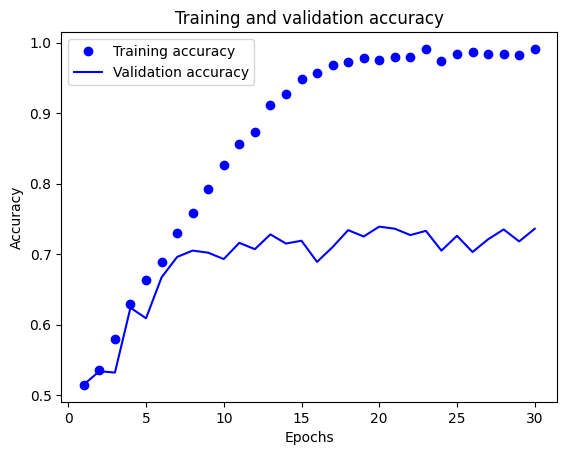

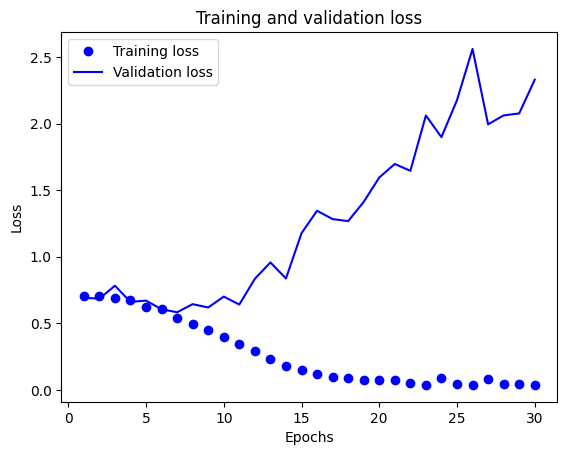

In [12]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### 테스트 세트에서 모델 평가하기

In [13]:
test_model = keras.models.load_model("convert_from_scratch.h5")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"테스트 정확도: {test_acc:.3f}")

63/63 [==============================] - 7s 111ms/step - loss: 0.5730 - accuracy: 0.7020
테스트 정확도: 0.702


#### 데이터 증식 단계 정의하기

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

2026-03-19 15:02:50.144248: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-19 15:02:50.144290: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-19 15:02:52.950892: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-03-19 15:02:52.950931: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-03-19 15:02:52.951020: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-03-19 15:02:52.952851: I tensorflow/core/platform/cpu_fe

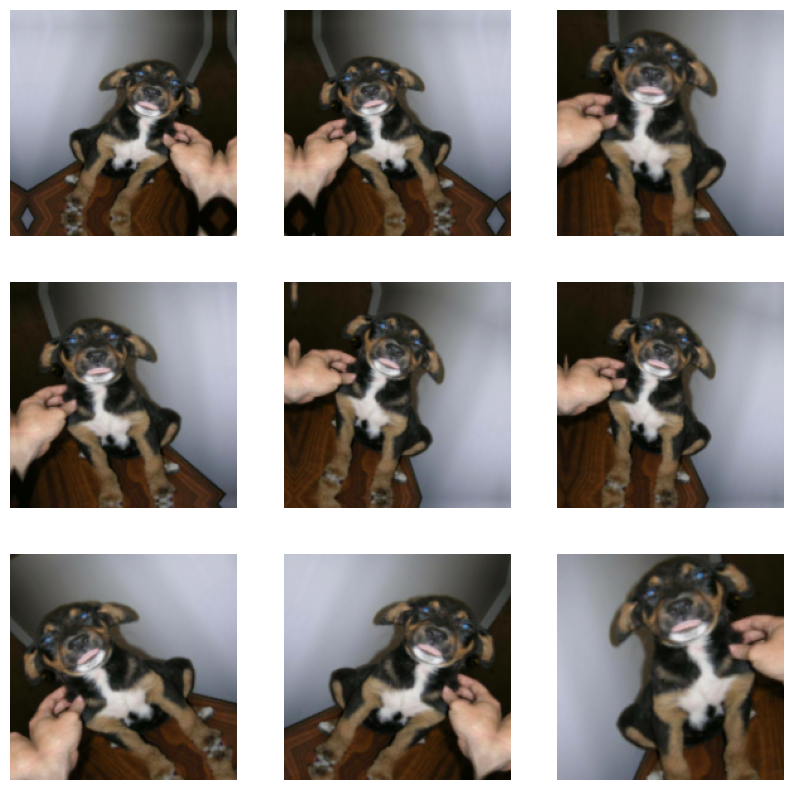

In [4]:
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow((augmented_images[0].numpy().astype("uint8")))
        plt.axis("off")

#### 이미지 증식과 드롭아웃을 포함한 컨브넷 만들기

In [5]:
inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters = 32, kernel_size = 3, activation = 'relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.h5",
        save_best_only=True,
        monitor="val_loss"
    )
]
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/100
63/63 [==============================] - 33s 502ms/step - loss: 0.7014 - accuracy: 0.5200 - val_loss: 0.7152 - val_accuracy: 0.5000
Epoch 2/100
63/63 [==============================] - 26s 411ms/step - loss: 0.7090 - accuracy: 0.5305 - val_loss: 0.6845 - val_accuracy: 0.5090
Epoch 3/100
63/63 [==============================] - 26s 408ms/step - loss: 0.7030 - accuracy: 0.5750 - val_loss: 0.6636 - val_accuracy: 0.5880
Epoch 4/100
63/63 [==============================] - 28s 453ms/step - loss: 0.6596 - accuracy: 0.6195 - val_loss: 0.6193 - val_accuracy: 0.6650
Epoch 5/100
63/63 [==============================] - 27s 434ms/step - loss: 0.6469 - accuracy: 0.6480 - val_loss: 0.6408 - val_accuracy: 0.6150
Epoch 6/100
63/63 [==============================] - 30s 479ms/step - loss: 0.6222 - accuracy: 0.6680 - val_loss: 0.6050 - val_accuracy: 0.6770
Epoch 7/100
63/63 [==============================] - 30s 468ms/step - loss: 0.6043 - accuracy: 0.6730 - val_loss: 0.5765 - val_accuracy:

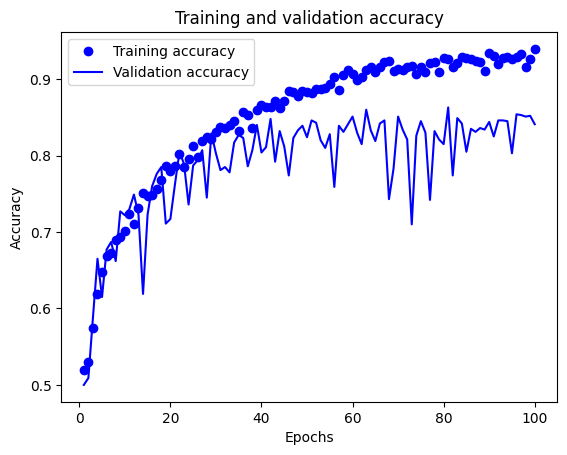

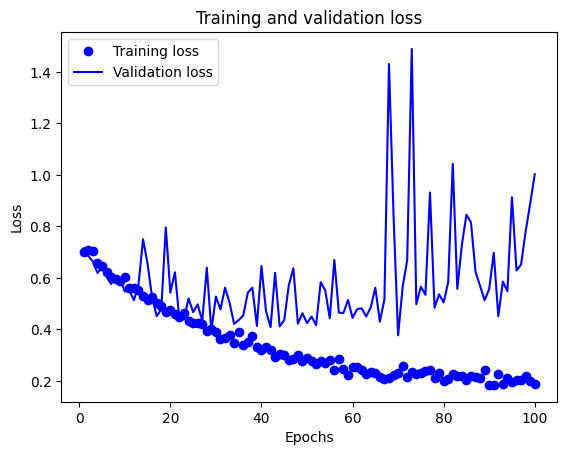

In [6]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [4]:
from tensorflow import keras

test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.h5"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"테스트 정확도: {test_acc:.3f}")

63/63 [==============================] - 6s 86ms/step - loss: 0.5062 - accuracy: 0.8450
테스트 정확도: 0.845


#### VGG16 합성곱 기반 층 만들기

In [ ]:
from pathlib import Path
from tensorflow.keras.utils import image_dataset_from_directory

new_base_dir = Path('./datasets/cats_and_dogs_small')

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size = (180, 180),
    batch_size = 32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size = (180, 180),
    batch_size = 32)

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet", # 사전 훈련된 가중치를 사용합니다. imagenet 데이터셋에서 훈련된 가중치를 사용합니다.
    include_top=False, # Dense (분류기) 부분 제거
    input_shape=(180,180,3) 
)

58900480/58889256 [==============================] - 4s 0us/step


In [6]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 180, 180, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 180, 180, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 90, 90, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 90, 90, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 90, 90, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 45, 45, 128)       0     

## Notes

##### 합성곱 연산

- 학습된 패턴은 평행 이동 불변성을 가진다. 컨브넷이 이미지의 오른쪽 아래 모서리에서 어떤 패턴을 학습했다면 다른 곳에서도 이 패턴을 인식할 수 있다. 완전 연결 네트워크는 새로운 위치에 나타난 것은 새로운 패턴으로 학습해야 한다. 

- 컨브넷은 패턴의 공간적 계층 구조를 학습할 수 있다. 합성곱 연산은 특성 맵이라고 부르는 랭크-3 텐서에 적용된다. 이 텐서는 2개의 공간 축과 깊이 축으로 구성된다. RGB 이미지는 3개의 컬러 채널을 가지므로 깊이 축의 차원이 3이 된다. MNIST 숫자처럼 흑백 이미지는 깊이 축의 차원이 1입니다. 합성곱 연산은 입력 특성 맵에서 작은 패치들을 추출하고 이런 모든 패치에 같은 변환을 적용하여 출력 특성 맵을 만든다.

##### 경계 구조와 패딩

- 5 x 5 크기의 특성 맵을 생각해 볼때, 3 x 3 크기인 윈도우를 사용할때에 출력 특성 맵은 3 x 3 크기가 된다. 그런데 입력과 동일한 높이와 너비를 가진 출력 특성 맵을 얻고 싶다면 *패딩*을 사용해서, *가장자리에 적절한 개수의 행과 열을 추가*함으로써, 모든 입력 타일에 합성곱 윈도우의 중앙을 위치시킬 수 있다. 

##### 합성곱 스트라이드 이해하기

- 출력 크기에 영향을 미치는 다른 요소는 스트라이드이다. 스트라이드는 간단하게 말해 커널이 한번에 몇 칸 움직일까에 대한 설명이다. 즉, *두번의 연속적인 윈도우 사이의 거리*를 *스트라이드*라고 부른다.

##### 풀링과 다운샘플링

- *다운샘플링*을 사용하는 이유는, 처리할 특성 맵의 가중치 개수를 줄이기 위해서이다. 또한, 연속적인 합성곱 층이 점점 커진 윈도우를 통해 바라보도록 만들어 필터의 공간적인 계층 구조를 구성한다.

- 최대 풀링이 다운샘플링을 할 수 있는 유일한 방법은 아니다. 이미 알고 있듯이, 앞선 합성곱 층에서 스트라이드를 사용할 수 있다. 최댓값을 취하는 최대 풀링 대신에 입력 패치의 채널별 평균값을 계산하여 변환하는 평균 풀링을 사용할 수도 있다.